# Access and Orthorectify of PRISM L1B Radiance from PACE-PAX

## Overview

The Portable Remote Imaging SpectroMeter ([PRISM](https://www.earthdata.nasa.gov/data/instruments/prism)) is a compact airborne pushbroom imaging spectrometer built by the NASA Jet Propulsion Laboratory (JPL) for studies of coastal and inland waters. PRISM instrument covers spectral range from 350–1050 nm with with a 2.83 nm sampling per pixel, and a 0.88 mrad instantaneous field of view, with 608 cross-track pixels in a pushbroom configuration ([Mouroulis et al., 2014](https://doi.org/10.1364/AO.53.001363)).

In September 2024, PRISM flew on the NASA ER-2 high-altitude aircraft for the **Plankton, Aerosol, Cloud, ocean Ecosystem Postlaunch Airborne eXperiment ([PACE-PAX](https://www.earthdata.nasa.gov/data/projects/pace-pax))**. PACE-PAX was a field campaign over Southern and Central California and adjacent coastal waters that collected validation data for the NASA [PACE](https://www.earthdata.nasa.gov/data/platforms/space-based-platforms/pace) satellite and the JAXA/ESA [EarthCARE](https://www.eorc.jaxa.jp/EARTHCARE/) satellite. The [NASA ER-2](https://www.earthdata.nasa.gov/data/platforms/air-based-platforms/nasa-er-2) flew 13 research flights with six instruments that act as airborne proxies for the satellite sensors. PRISM covers lower-reflectance spectra for ocean colors, while PICARD has VNIR to SWIR channels. PRISM, together with the PICARD imaging spectrometer, matches capabilities of the PACE Ocean Color Instrument (OCI) ([Knobelspiesse et al., 2026](https://doi.org/10.5194/essd-2026-541)). The campaign sampled ocean color, aerosols, and clouds, including wildfire smoke over the Los Angeles region and red tide events in Monterey Bay.

In this tutorial, we use [earthaccess](https://earthaccess.readthedocs.io/) to discover and download [PRISM Level 1B (L1B) calibrated radiance for PACE-PAX](https://doi.org/10.3334/ORNLDAAC/2515). We then use a geometric lookup table (GLT) to orthorectify the image, and compare radiance spectra of water, sand, vegetation, and urban surfaces over Monterey Bay, California.

### Dataset

| Dataset | DOI | Short Name |
|---|---|---|
| PRISM: L1B Calibrated Radiance for PACE-PAX, 2024 | [10.3334/ORNLDAAC/2515](https://doi.org/10.3334/ORNLDAAC/2515) | PRISM_L1B_PACEPAX_2024_2515 |

The dataset contains **2,223 NetCDF-4 files**, each about 600 MB in size. Please refer to the [user guide](https://data.ornldaac.earthdata.nasa.gov/public/prism/PRISM_L1B_PACEPAX_2024/comp/PRISM_L1B_PACEPAX_2024.pdf) for full dataset documentation.

### Learning Objectives

- Search the PRISM PACE-PAX collection and its granules with `earthaccess`
- Stream a granule and explore its data structure
- Orthorectify a calibrated radiance using the geometric lookup table (GLT)
- Export an orthorectified image as a Cloud Optimized GeoTIFF

### Prerequisites

A free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account is required. See the [prerequisites](../../docs/prerequisites.md) page for setup instructions.

## Import Libraries

In [1]:
import earthaccess
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray
import pyproj
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore')

xyz = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
attr = "ESRI"

## Authentication

Use `earthaccess.login()` to authenticate with your NASA Earthdata Login credentials. If you have a `.netrc` file configured, login will complete without a prompt.

In [2]:
auth = earthaccess.login()

## Search for the PRISM PACE-PAX Collection

We search for the datasets from the PRISM instrument using `earthaccess`.

In [3]:
instrument = "PRISM"
datasets = earthaccess.search_datasets(instrument=instrument)
print(f"{instrument} datasets found: {len(datasets)}\n")
for ds in datasets:
    summary = ds.summary()
    print(f"  Short name : {summary.get('short-name', 'N/A')}")

PRISM datasets found: 28

  Short name : ALOS_PRISM_L1B
  Short name : BioSCape_PRISM_L1B_RDN_2493
  Short name : BioSCape_PRISM_L2A_RFL_2494
  Short name : CEOS_CalVal_Test_Site-Dome_C-Antarctica
  Short name : CEOS_CalVal_Test_Site-Dunhuang-China
  Short name : CEOS_CalVal_Test_Site-Frenchman_Flat-USA
  Short name : CEOS_CalVal_Test_Site-Ivanpah_Playa-USA
  Short name : CEOS_CalVal_Test_Site-La_Crau-France
  Short name : CEOS_CalVal_Test_Site-Libya1
  Short name : CEOS_CalVal_Test_Site-Libya4
  Short name : CEOS_CalVal_Test_Site-Mauritania1
  Short name : CEOS_CalVal_Test_Site-Negev-Southern_Israel
  Short name : CEOS_CalVal_Test_Site-Railroad_Valley_Playa-USA
  Short name : CEOS_CalVal_Test_Site-Tuz_Golu-Turkey
  Short name : CEOS_CalVal_Test_Sites-Algeria3
  Short name : CEOS_CalVal_Test_Sites-Algeria5
  Short name : CEOS_CalVal_Test_Sites-Mauritania2
  Short name : CNDP_CNDP_20240203_GEOCHEM_DATA
  Short name : PACE-PAX_AircraftRemoteSensing_ER2_PRISM-PICARD-L1C_Data
  Short name 

There are many datasets from the PRISM instruments published so far. We will use `PRISM_L1B_PACEPAX_2024_2515` dataset and print key metadata.

In [4]:
shortname = "PRISM_L1B_PACEPAX_2024_2515"
collections = earthaccess.search_datasets(short_name=shortname)

for c in collections:
    temporal = c.get_umm('TemporalExtents')[0]['RangeDateTimes'][0]
    print(f"Title      : {c.get_umm('EntryTitle')}")
    print(f"ShortName  : {c.get_umm('ShortName')}")
    print(f"Temporal   : {temporal['BeginningDateTime']} to {temporal['EndingDateTime']}")
    size = c.get_umm('ArchiveAndDistributionInformation')['FileDistributionInformation'][0]
    print(f"Total size : {size['TotalCollectionFileSize']} {size['TotalCollectionFileSizeUnit']}")

Title      : PRISM: L1B Calibrated Radiance for PACE-PAX, 2024
ShortName  : PRISM_L1B_PACEPAX_2024_2515
Temporal   : 2024-09-04T00:00:00.000Z to 2024-09-30T23:59:59.999Z
Total size : 1.252 TB


## Search for Granules

Each granule is one **scene** from a PRISM flight line. The file names follow the convention:

`PACEPAX-PRISM-L1B_ER2_<YYYYMMDDhhmmss>_R0_<scene>.nc`

where `<YYYYMMDDhhmmss>` is the start time of the flight line (UTC), `R0` is the processing revision, and `<scene>` is the three-digit scene number within the flight line. We search for all granules in the collection and parse the flight line and scene from each file name.

In [5]:
short_name = 'PRISM_L1B_PACEPAX_2024_2515'
granules = earthaccess.search_data(short_name=short_name)
print(f"Granules found: {len(granules)}")

Granules found: 2223


Let's split the granule names into flight and scene.

In [6]:
def granule_details(g):
    gname = g.data_links()[0].split('/')[-1]
    sp = gname.removesuffix('.nc').split('_')
    return {
        'file': gname,
        'flight_line': sp[2],
        'scene': sp[-1],
        'start_time': pd.to_datetime(g['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime']),
        'size_mb': g.size(),
    }

df_granules = pd.DataFrame([granule_details(g) for g in granules])
df_granules.head()

,file,flight_line,scene,start_time,size_mb
0,PACEPAX-PRISM-L1B_ER2_20240904190309_R0_000.nc,20240904190309,000,2024-09-04 19:05:06+00:00,612.701657
1,PACEPAX-PRISM-L1B_ER2_20240904190309_R0_001.nc,20240904190309,001,2024-09-04 19:05:59+00:00,612.702249
2,PACEPAX-PRISM-L1B_ER2_20240904190309_R0_002.nc,20240904190309,002,2024-09-04 19:06:53+00:00,610.078081
3,PACEPAX-PRISM-L1B_ER2_20240904190309_R0_003.nc,20240904190309,003,2024-09-04 19:07:46+00:00,605.355297
4,PACEPAX-PRISM-L1B_ER2_20240904190309_R0_004.nc,20240904190309,004,2024-09-04 19:08:40+00:00,605.354929


We summarize the scenes by flight day. PRISM collected data for several flight days between 4 and 30 September 2024.

In [7]:
df_granules['date'] = df_granules['start_time'].dt.date
df_granules.groupby('date').agg(
    flight_lines=('flight_line', 'nunique'),
    scenes=('file', 'count'),
    size_gb=('size_mb', lambda s: round(s.sum() / 1000, 1)),
)

,flight_lines,scenes,size_gb
date,,,
2024-09-04,6,156,95.8
2024-09-06,6,75,46.5
2024-09-08,3,59,35.8
2024-09-10,6,99,61.4
2024-09-13,14,267,165.1
2024-09-15,8,89,56.0
2024-09-17,22,246,154.1
2024-09-22,15,228,141.4
2024-09-23,13,251,153.5


## Find granules over Monterey Bay

Monterey Bay was a key PACE-PAX ocean target. A red tide was observed during the campaign ([Knobelspiesse et al., 2026](https://doi.org/10.5194/essd-2026-541)). 

We search for granules that intersect a bounding box over Monterey bay and map their footprints.

In [8]:
# bounding box (west, south, east, north) over Monterey Bay, California
bbox = (-122.2, 36.5, -121.75, 37.05)

granules_mb = earthaccess.search_data(short_name=short_name, 
                                      bounding_box=bbox)
print(f"Granules over Monterey Bay: {len(granules_mb)}")

Granules over Monterey Bay: 55


Let's convert the granules to a geopandas dataframe and print summary details.

In [9]:
# convert to geopandas
gdf = gpd.GeoDataFrame(
    [granule_details(g) for g in granules_mb],
    geometry=gpd.GeoSeries(granules_mb, crs=4326),
)
gdf['start_time'] = gdf['start_time'].astype(str)
gdf.groupby('flight_line').size().rename('scenes').to_frame()

,scenes
flight_line,
20240904220628,6
20240908221829,6
20240923180335,6
20240926181605,7
20240926184455,7
20240926211935,5
20240927191525,6
20240927193343,6
20240927230405,6


In [10]:
# plot granule footprints, colored by flight line
gdf.explore(
    column='flight_line', tiles=xyz, attr=attr, cmap='tab10',
    style_kwds={"weight": 2, "fillOpacity": 0.5},
    tooltip=['file', 'start_time'],
)

### Preview a granule

Each granule has an associated quick-look browse image, which can be used to scan the scene for any cloud cover and pick a clear scene. One of the clear scene is flight line `20240926181605`, scene `019`, acquired on 26 September 2024 over the area.

In [11]:
granule_name = 'PACEPAX-PRISM-L1B_ER2_20240926181605_R0_019.nc'
granule = [g for g in granules_mb if g.data_links()[0].endswith(granule_name)][0]

# browse image link
browse_url = granule.dataviz_links()[0]
print(browse_url)
display(Image(url=browse_url, width=450))

https://data.ornldaac.earthdata.nasa.gov/public/prism/PRISM_L1B_PACEPAX_2024/browse/PACEPAX-PRISM-L1B_ER2_20240926181605_R0_019_BROWSE.png


## Open a Granule

We open and stream the granule with `earthaccess.open()`. 

In [12]:
f = earthaccess.open([granule])[0]
print(f"Granule opened: {f}")


Granule opened: <File-like object HTTPFileSystem, https://data.ornldaac.earthdata.nasa.gov/protected/prism/PRISM_L1B_PACEPAX_2024/data/PACEPAX-PRISM-L1B_ER2_20240926181605_R0_019.nc>


## Explore the NetCDF File Structure

PRISM L1B files are NetCDF-4 files with **groups**. We open the whole file as an `xarray.DataTree` to see all groups at once.

In [13]:
dt = xr.open_datatree(f, engine='h5netcdf')
dt

<xarray.DataTree>
Group: /
│   Dimensions:              (lines: 640, samples: 606)
│   Dimensions without coordinates: lines, samples
│   Data variables:
│       lat                  (lines, samples) float32 2MB ...
│       lon                  (lines, samples) float32 2MB ...
│       elev                 (lines, samples) float32 2MB ...
│       transverse_mercator  |S1 1B ...
│   Attributes: (12/23)
│       Conventions:                       CF-1.6
│       date_created:                      2025-01-16T11:06:04Z
│       summary:                           The Portable Remote Imaging Spectromet...
│       keywords:                          Imaging Spectroscopy, PRISM
│       sensor:                            Portable Remote Imaging Spectrometer
│       instrument:                        PRISM
│       ...                                ...
│       ncei_template_version:             NCEI_NetCDF_Swath_Template_v2.0
│       title:                             PRISM L1B Calibrated Radiance (flight ...
│       processing_level:                  L1B
│       time_coverage_start:               2024-09-26T18:33:26Z
│       time_coverage_end:                 2024-09-26T18:34:20Z
│       product_version:                   0
├── Group: /geolocation_lookup_table
│       Dimensions:   (northing: 672, easting: 652)
│       Coordinates:
│         * northing  (northing) float64 5kB 4.058e+06 4.058e+06 ... 4.046e+06 4.046e+06
│         * easting   (easting) float64 5kB 5.953e+05 5.953e+05 ... 6.069e+05 6.069e+05
│       Data variables:
│           sample    (northing, easting) float32 2MB ...
│           line      (northing, easting) float32 2MB ...
│       Attributes:
│           long_name:    Geolocation lookup table
│           description:  Orthocorrected product with a fixed pixel size projected in...
└── Group: /radiance
        Dimensions:     (wavelength: 246, lines: 640, samples: 606)
        Coordinates:
          * wavelength  (wavelength) float32 984B 350.6 353.4 ... 1.043e+03 1.046e+03
        Dimensions without coordinates: lines, samples
        Data variables:
            radiance    (wavelength, lines, samples) float32 382MB ...
            fwhm        (wavelength) float32 984B ...

The file has three parts:

| Group | Variables | Description |
|---|---|---|
| `/` (root) | `lat`, `lon`, `elev` | Latitude, longitude, and surface elevation for each pixel in the **raw** (sensor) geometry, with dimensions (`lines`, `samples`). |
| `/radiance` | `radiance`, `wavelength`, `fwhm` | Calibrated at-sensor radiance (µW nm⁻¹ cm⁻² sr⁻¹) with dimensions (`wavelength`, `lines`, `samples`), plus band center wavelengths and full width at half maximum (FWHM). |
| `/geolocation_lookup_table` | `line`, `sample`, `easting`, `northing` | The geometric lookup table (GLT): a north-up UTM grid where each cell stores the raw `line` and `sample` of the pixel that belongs there. |

The radiance is in the **raw geometry** of the pushbroom sensor, which is not orthorectified. `lines` is the along-track direction (flight direction) and `samples` is the across-track direction. The nodata value is -9999; `xarray` masks it as `NaN` automatically.

We extract each group as an `xarray.Dataset`.

In [14]:
root = dt.to_dataset()
rad = dt['radiance'].to_dataset()
glt = dt['geolocation_lookup_table'].to_dataset()

print(dt.attrs['title'])
print(f"Acquisition: {dt.attrs['time_coverage_start']} to {dt.attrs['time_coverage_end']}")
print(f"Radiance shape (wavelength, lines, samples): {rad['radiance'].shape}")
print(f"GLT shape (northing, easting): {glt['line'].shape}")

PRISM L1B Calibrated Radiance (flight line: prm20240926t181605, scene: 019)
Acquisition: 2024-09-26T18:33:26Z to 2024-09-26T18:34:20Z
Radiance shape (wavelength, lines, samples): (246, 640, 606)
GLT shape (northing, easting): (672, 652)


The UTM zone of the GLT differs between flight lines (from UTM zones 9N to 12N in this dataset). The coordinate reference system (CRS) is stored in the `transverse_mercator` variable.

In [15]:
crs = pyproj.CRS.from_wkt(dt['transverse_mercator'].attrs['crs_wkt'])
pixel_size = float(glt['easting'].diff('easting')[0])
print(f"CRS: {crs.name} (EPSG:{crs.to_epsg()})")
print(f"GLT pixel size: {pixel_size:.1f} m")

CRS: WGS 84 / UTM zone 10N (EPSG:32610)
GLT pixel size: 17.9 m


## Spectral Characteristics

PRISM measures 246 contiguous spectral bands, with following details.

In [16]:
wl = rad['wavelength']
fwhm = rad['fwhm']
print(f"Number of bands : {wl.size}")
print(f"Wavelength range : {wl.min():.1f} to {wl.max():.1f} nm")
print(f"Band spacing : {np.diff(wl).mean():.2f} nm")
print(f"FWHM range : {fwhm.min():.2f} to {fwhm.max():.2f} nm")

Number of bands : 246
Wavelength range : 350.6 to 1045.6 nm
Band spacing : 2.84 nm
FWHM range : 3.28 to 4.58 nm


We plot the band center wavelengths against their FWHM to describe spectral resolution of each band.

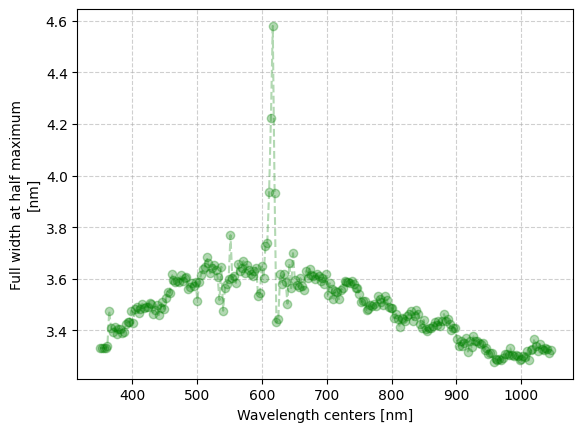

In [17]:
fwhm.plot.line("g--", marker="o", alpha=0.3)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Calibrated Radiance True Color Image (Unorthorectified)

We select red (640 nm), green (550 nm), and blue (460 nm) bands to make a true-color image. 

Because radiance values vary widely between bands, we apply a 2-98% percentile stretch to each band.

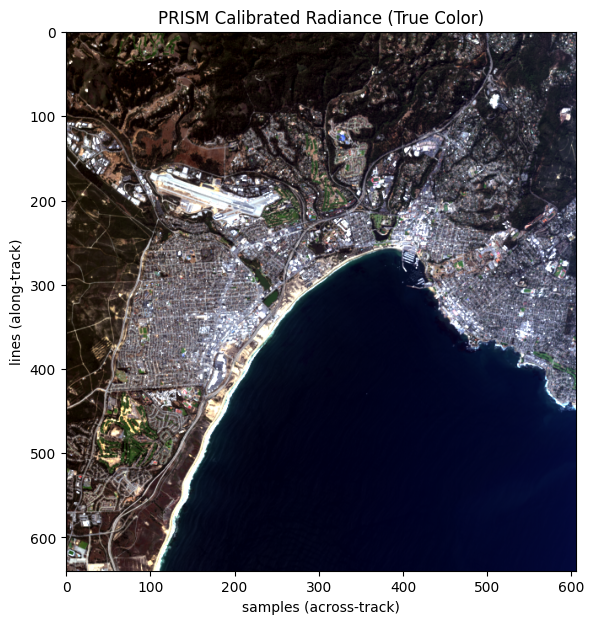

In [18]:
def stretch(band, lower=2, upper=98):
    """percentile stretch to the 0-1 range"""
    p_low, p_high = np.nanpercentile(band, [lower, upper])
    return np.clip((band - p_low) / (p_high - p_low), 0, 1)

rgb_wl = [640, 550, 460]
rgb_raw = rad['radiance'].sel(wavelength=rgb_wl, method='nearest').load()

rgb_raw_img = np.dstack([stretch(b) for b in rgb_raw.values])

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(rgb_raw_img)
ax.set_xlabel('samples (across-track)')
ax.set_ylabel('lines (along-track)')
ax.set_title('PRISM Calibrated Radiance (True Color)')
plt.show()

Note that the image above is not orthorectified.

## Orthorectify with the Geometric Lookup Table

The GLT (`geolocation_lookup_table`) provides a grid in UTM coordinates. Each GLT pixel stores the raw `line` and `sample` of the pixel that falls there:

The function below uses the GLT to resample any raw array onto the UTM grid. It returns an `xarray.DataArray` with `x`/`y` coordinates and the CRS attached.

In [19]:
def orthorectify(data, glt, crs):
    # map a (..., lines, samples) raw-geometry array onto the GLT's UTM grid
    line = glt['line'].values
    sample = glt['sample'].values
    valid = ~np.isnan(line)
    # lines/samples starts with 1
    # subtracting 1 to convert to 0-based index
    # converting both -ve/+ve values to absolute
    li = np.abs(line[valid]).astype(int) - 1   
    si = np.abs(sample[valid]).astype(int) - 1

    data = np.asarray(data)
    out = np.full(data.shape[:-2] + line.shape,
                  np.nan, dtype=np.float32)
    out[..., valid] = data[..., li, si]

    da = xr.DataArray(out, dims=('band', 'y', 'x'),
                      coords={'y': glt['northing'].values, 
                              'x': glt['easting'].values})
    return da.rio.write_crs(crs)

rgb_ortho = orthorectify(rgb_raw.values, glt, crs)
rgb_ortho = rgb_ortho.assign_coords(band=rgb_raw['wavelength'].values)
rgb_ortho

<xarray.DataArray (band: 3, y: 672, x: 652)> Size: 5MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(3, 672, 652), dtype=float32)
Coordinates:
  * band         (band) float32 12B 639.5 548.8 461.0
  * y            (y) float64 5kB 4.058e+06 4.058e+06 ... 4.046e+06 4.046e+06
  * x            (x) float64 5kB 5.953e+05 5.953e+05 ... 6.069e+05 6.069e+05
    spatial_ref  int64 8B 0

Now we plot the raw and orthorectified images side by side.

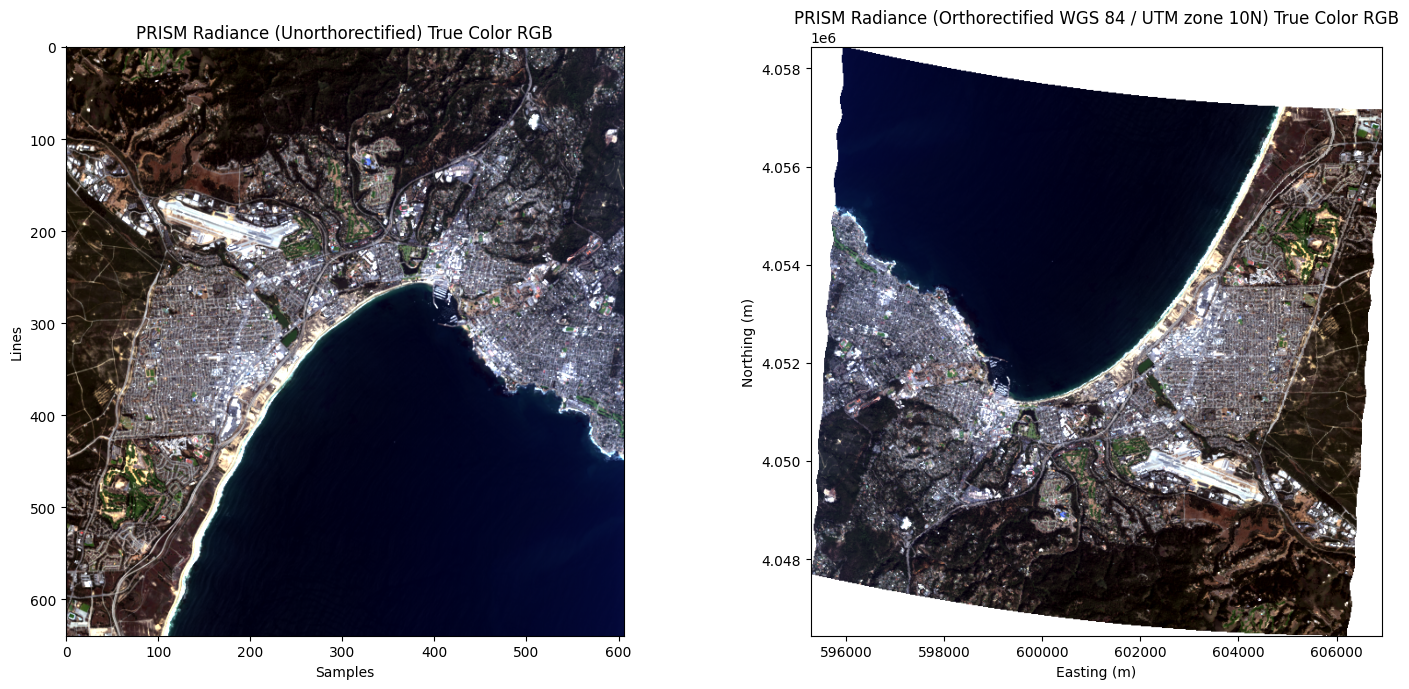

In [20]:
rgb_ortho_img = np.dstack([stretch(b) for b in rgb_ortho.values])
# show pixels outside the swath as white
rgb_ortho_img[np.isnan(rgb_ortho.values[0])] = 1

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(rgb_raw_img)
axes[0].set_title('PRISM Radiance (Unorthorectified) True Color RGB')
axes[0].set_xlabel('Samples')
axes[0].set_ylabel('Lines')

extent = [float(rgb_ortho.x.min()), float(rgb_ortho.x.max()),
          float(rgb_ortho.y.min()), float(rgb_ortho.y.max())]
axes[1].imshow(rgb_ortho_img, extent=extent)
axes[1].set_title(f"PRISM Radiance (Orthorectified {crs.name}) True Color RGB")
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

## Map the Orthorectified Image

Because the orthorectified image has a CRS, we can plot it on a basemap. We will use `cartopy` in the PRISM data's native UTM projection to avoid resampling.

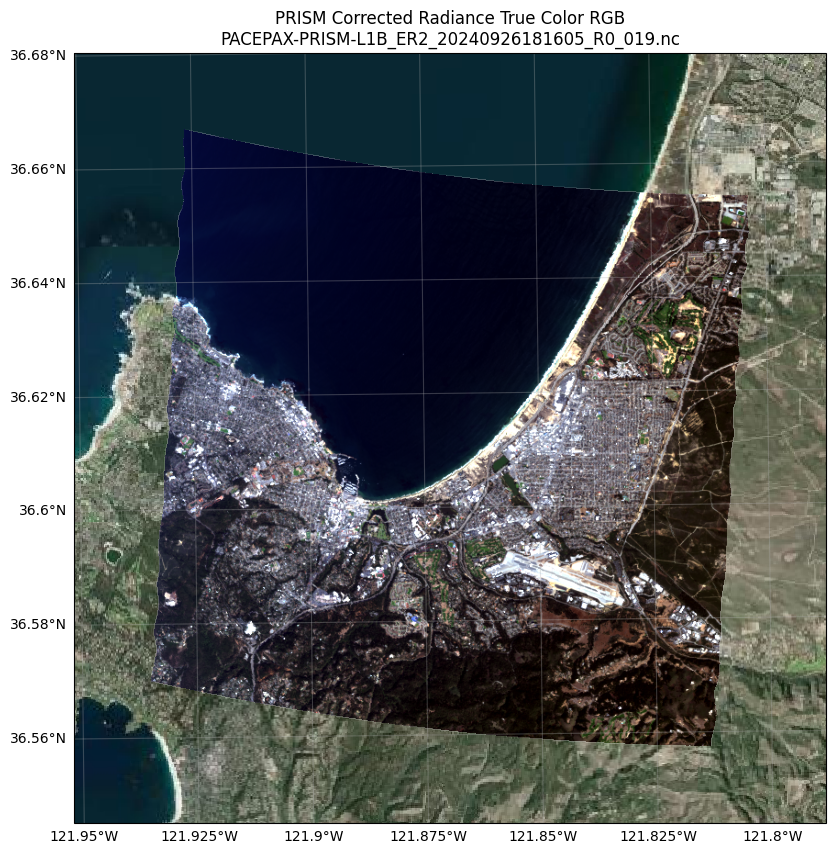

In [21]:
# add an alpha band for transparent pixels for nan
swath = ~np.isnan(rgb_ortho.values[0])
rgba = np.dstack([rgb_ortho_img, swath.astype(float)])

# UTM projection
proj = ccrs.epsg(crs.to_epsg())
tiles = cimgt.GoogleTiles(url=xyz)

# buffer of 1.5 km around image
pad = 1500
map_extent = [extent[0] - pad, extent[1] + pad, 
              extent[2] - pad, extent[3] + pad]

# plot
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=proj)
ax.set_extent(map_extent, crs=proj)
ax.add_image(tiles, 12)
ax.imshow(rgba, extent=extent, origin='upper', transform=proj, zorder=2)
gl = ax.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = gl.right_labels = False
ax.set_title(f'PRISM Corrected Radiance True Color RGB\n{granule_name}')
plt.show()

## Radiance Spectra

Let's extract radiance spectra for four surface types - one each for open water, beach, vegetation, and urban surface. 

In [22]:
# points of interest (latitude, longitude)
points = {
    'Open water': (36.625, -121.87),
    'Beach sand': (36.623, -121.847),
    'Vegetation': (36.565, -121.850),
    'Urban': (36.612, -121.848),
}

lat = root['lat'].values
lon = root['lon'].values

spectra = {}
for name, (plat, plon) in points.items():
    # nearest pixel 
    dist = (lat - plat)**2 + ((lon - plon) * np.cos(np.radians(plat)))**2
    i, j = np.unravel_index(np.nanargmin(dist), dist.shape)
    spectra[name] = rad['radiance'].isel(lines=i, samples=j).values
    print(f"{name:<12} line={i:<4} sample={j:<4}")

Open water   line=424  sample=309 
Beach sand   line=424  sample=193 
Vegetation   line=36   sample=183 
Urban        line=352  sample=194 


We plot the radiance spectra using `pandas` plot feature.

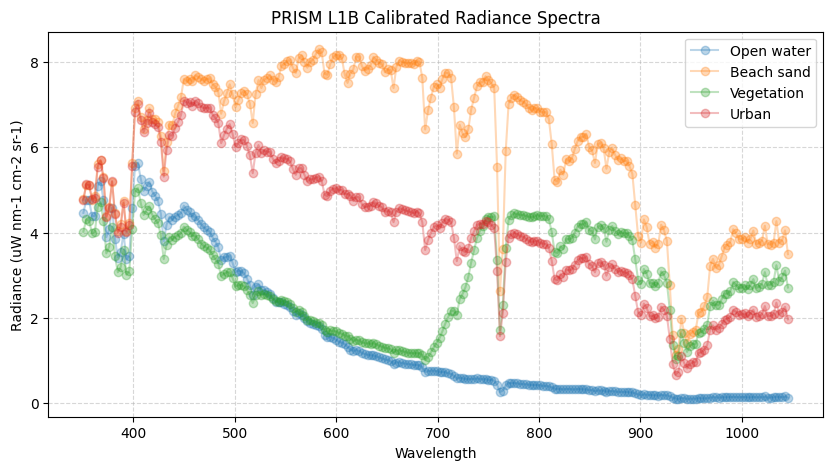

In [23]:
units = rad['radiance'].attrs['units']
spec_df = pd.DataFrame(spectra)
spec_df['Wavelength']=wl
spec_df.set_index('Wavelength', inplace=True)
spec_df.plot(marker="o", alpha=0.3, figsize=(10, 5),
            title='PRISM L1B Calibrated Radiance Spectra',
            ylabel=f"Radiance ({units})")
plt.grid(linestyle="--", alpha=0.5) 
plt.show()

In the above calibrated radiance spectral plot, **open water** is brightest in the blue and decreases toward the near infrared (NIR), where water absorbs almost all light. **Vegetation** shows the red edge, a sharp rise in radiance between ~680 and ~750 nm caused by chlorophyll absorption in the red and strong leaf scattering in the NIR. **Sand** and **urban** surfaces are bright across the spectrum.

## Export an Orthorectified GeoTIFF

The orthorectified array has a CRS and coordinates, so `rioxarray` can write it directly to a Cloud Optimized GeoTIFF (COG) for use in GIS software. As an example, here we export the orthorectified RGB true-color radiance bands.

In [24]:
out_tif = f"{granule_name}_RGB_ortho.tif"
rgb_ortho.rio.write_nodata(np.nan).rio.to_raster(out_tif, driver='COG')
print(f"Saved: {out_tif}")

Saved: PACEPAX-PRISM-L1B_ER2_20240926181605_R0_019.nc_RGB_ortho.tif
